# Demo notebook for LDData repository

## Example Point Generators

In [1]:
import qmcpy as qp

### Lattices

[qmcpy documentation for lattices](https://qmcpy.readthedocs.io/en/latest/algorithms.html#module-qmcpy.discrete_distribution.lattice.lattice)

In [2]:
lattice = qp.Lattice(  #set up a lattice
    dimension = 5,
    generating_vector = "kuo.lattice-33002-1024-1048576.9125.txt",
    randomize = False # set to True to apply random shift 
)
x = lattice(0,8) # points from index 0 (inclusive) to 8 (exclusive)
x

/Users/terrya/miniconda3/envs/lddata/lib/python3.13/site-packages/qmcpy/discrete_distribution/lattice/lattice.py:248: ParameterWarning: Without randomization, the first lattice point is the origin
  warnings.warn("Without randomization, the first lattice point is the origin",ParameterWarning)


array([[0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.5  , 0.5  , 0.5  , 0.5  , 0.5  ],
       [0.25 , 0.75 , 0.75 , 0.75 , 0.25 ],
       [0.75 , 0.25 , 0.25 , 0.25 , 0.75 ],
       [0.125, 0.375, 0.375, 0.875, 0.625],
       [0.625, 0.875, 0.875, 0.375, 0.125],
       [0.375, 0.125, 0.125, 0.625, 0.875],
       [0.875, 0.625, 0.625, 0.125, 0.375]])

### Digital Nets

[qmcpy documentation for digital nets](https://qmcpy.readthedocs.io/en/latest/algorithms.html#module-qmcpy.discrete_distribution.digital_net_b2.digital_net_b2)

In [3]:
dnb2 = qp.DigitalNetB2(
    dimension = 3,
    generating_matrices = "joe_kuo.4.5600.txt",
    randomize = False # set to True to apply left linear matrix scrambling with digital shift 
    # other randomization options are also supported
)
x = dnb2(0,8) # points from index 0 (inclusive) to 8 (exclusive)
x

/Users/terrya/miniconda3/envs/lddata/lib/python3.13/site-packages/qmcpy/discrete_distribution/digital_net_b2/digital_net_b2.py:421: ParameterWarning: Without randomization, the first digtial net point is the origin
  warnings.warn("Without randomization, the first digtial net point is the origin",ParameterWarning)


array([[0.   , 0.   , 0.   ],
       [0.5  , 0.5  , 0.5  ],
       [0.25 , 0.75 , 0.25 ],
       [0.75 , 0.25 , 0.75 ],
       [0.125, 0.625, 0.875],
       [0.625, 0.125, 0.375],
       [0.375, 0.375, 0.625],
       [0.875, 0.875, 0.125]])

## Plot Extensible Projections

In [4]:
import numpy as np 
import os
from matplotlib import pyplot
pyplot.style.use("seaborn-v0_8-whitegrid")

In [5]:
def plot_extensible_projections(generators, files, n, s=5):
    assert all(generator.d==generators[0].d for generator in generators)
    d = generators[0].d 
    nrows = len(generators)
    ncols = d*(d-1)//2 
    fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(5*ncols,5*nrows),sharex=True,sharey=True)
    ax = np.atleast_1d(ax).reshape((nrows,ncols))
    n = np.hstack([np.zeros(1,dtype=int),n])
    for i in range(nrows):
        x = generators[i].gen_samples(n[-1],warn=False)
        j = 0
        for j1 in range(d):
            for j2 in range(j1+1,d):
                for k in range(1,len(n)):
                    ax[i,j].scatter(x[n[k-1]:n[k],j1],x[n[k-1]:n[k],j2],s=s)
                ax[i,j].set_xlim([0,1])
                ax[i,j].set_ylim([0,1])
                ax[i,j].set_xticks([0,1/4,1/2,3/4,1])
                ax[i,j].set_yticks([0,1/4,1/2,3/4,1])
                ax[i,j].set_xticklabels([r"$0$",r"$1/4$",r"$1/2$",r"$3/4$",r"$1$"])
                ax[i,j].set_yticklabels([r"$0$",r"$1/4$",r"$1/2$",r"$3/4$",r"$1$"])
                ax[i,j].set_aspect(1)
                ax[0,j].set_title(r"$x_{%d} \quad\text{vs}\quad x_{%d}$"%(j1+1,j2+1),fontsize="xx-large")
                j += 1
        ax[i,0].set_ylabel(files[i],fontsize="xx-large")
    fig.tight_layout()

In [6]:
d = 4
n = np.array([256,512,1024])

### Lattices

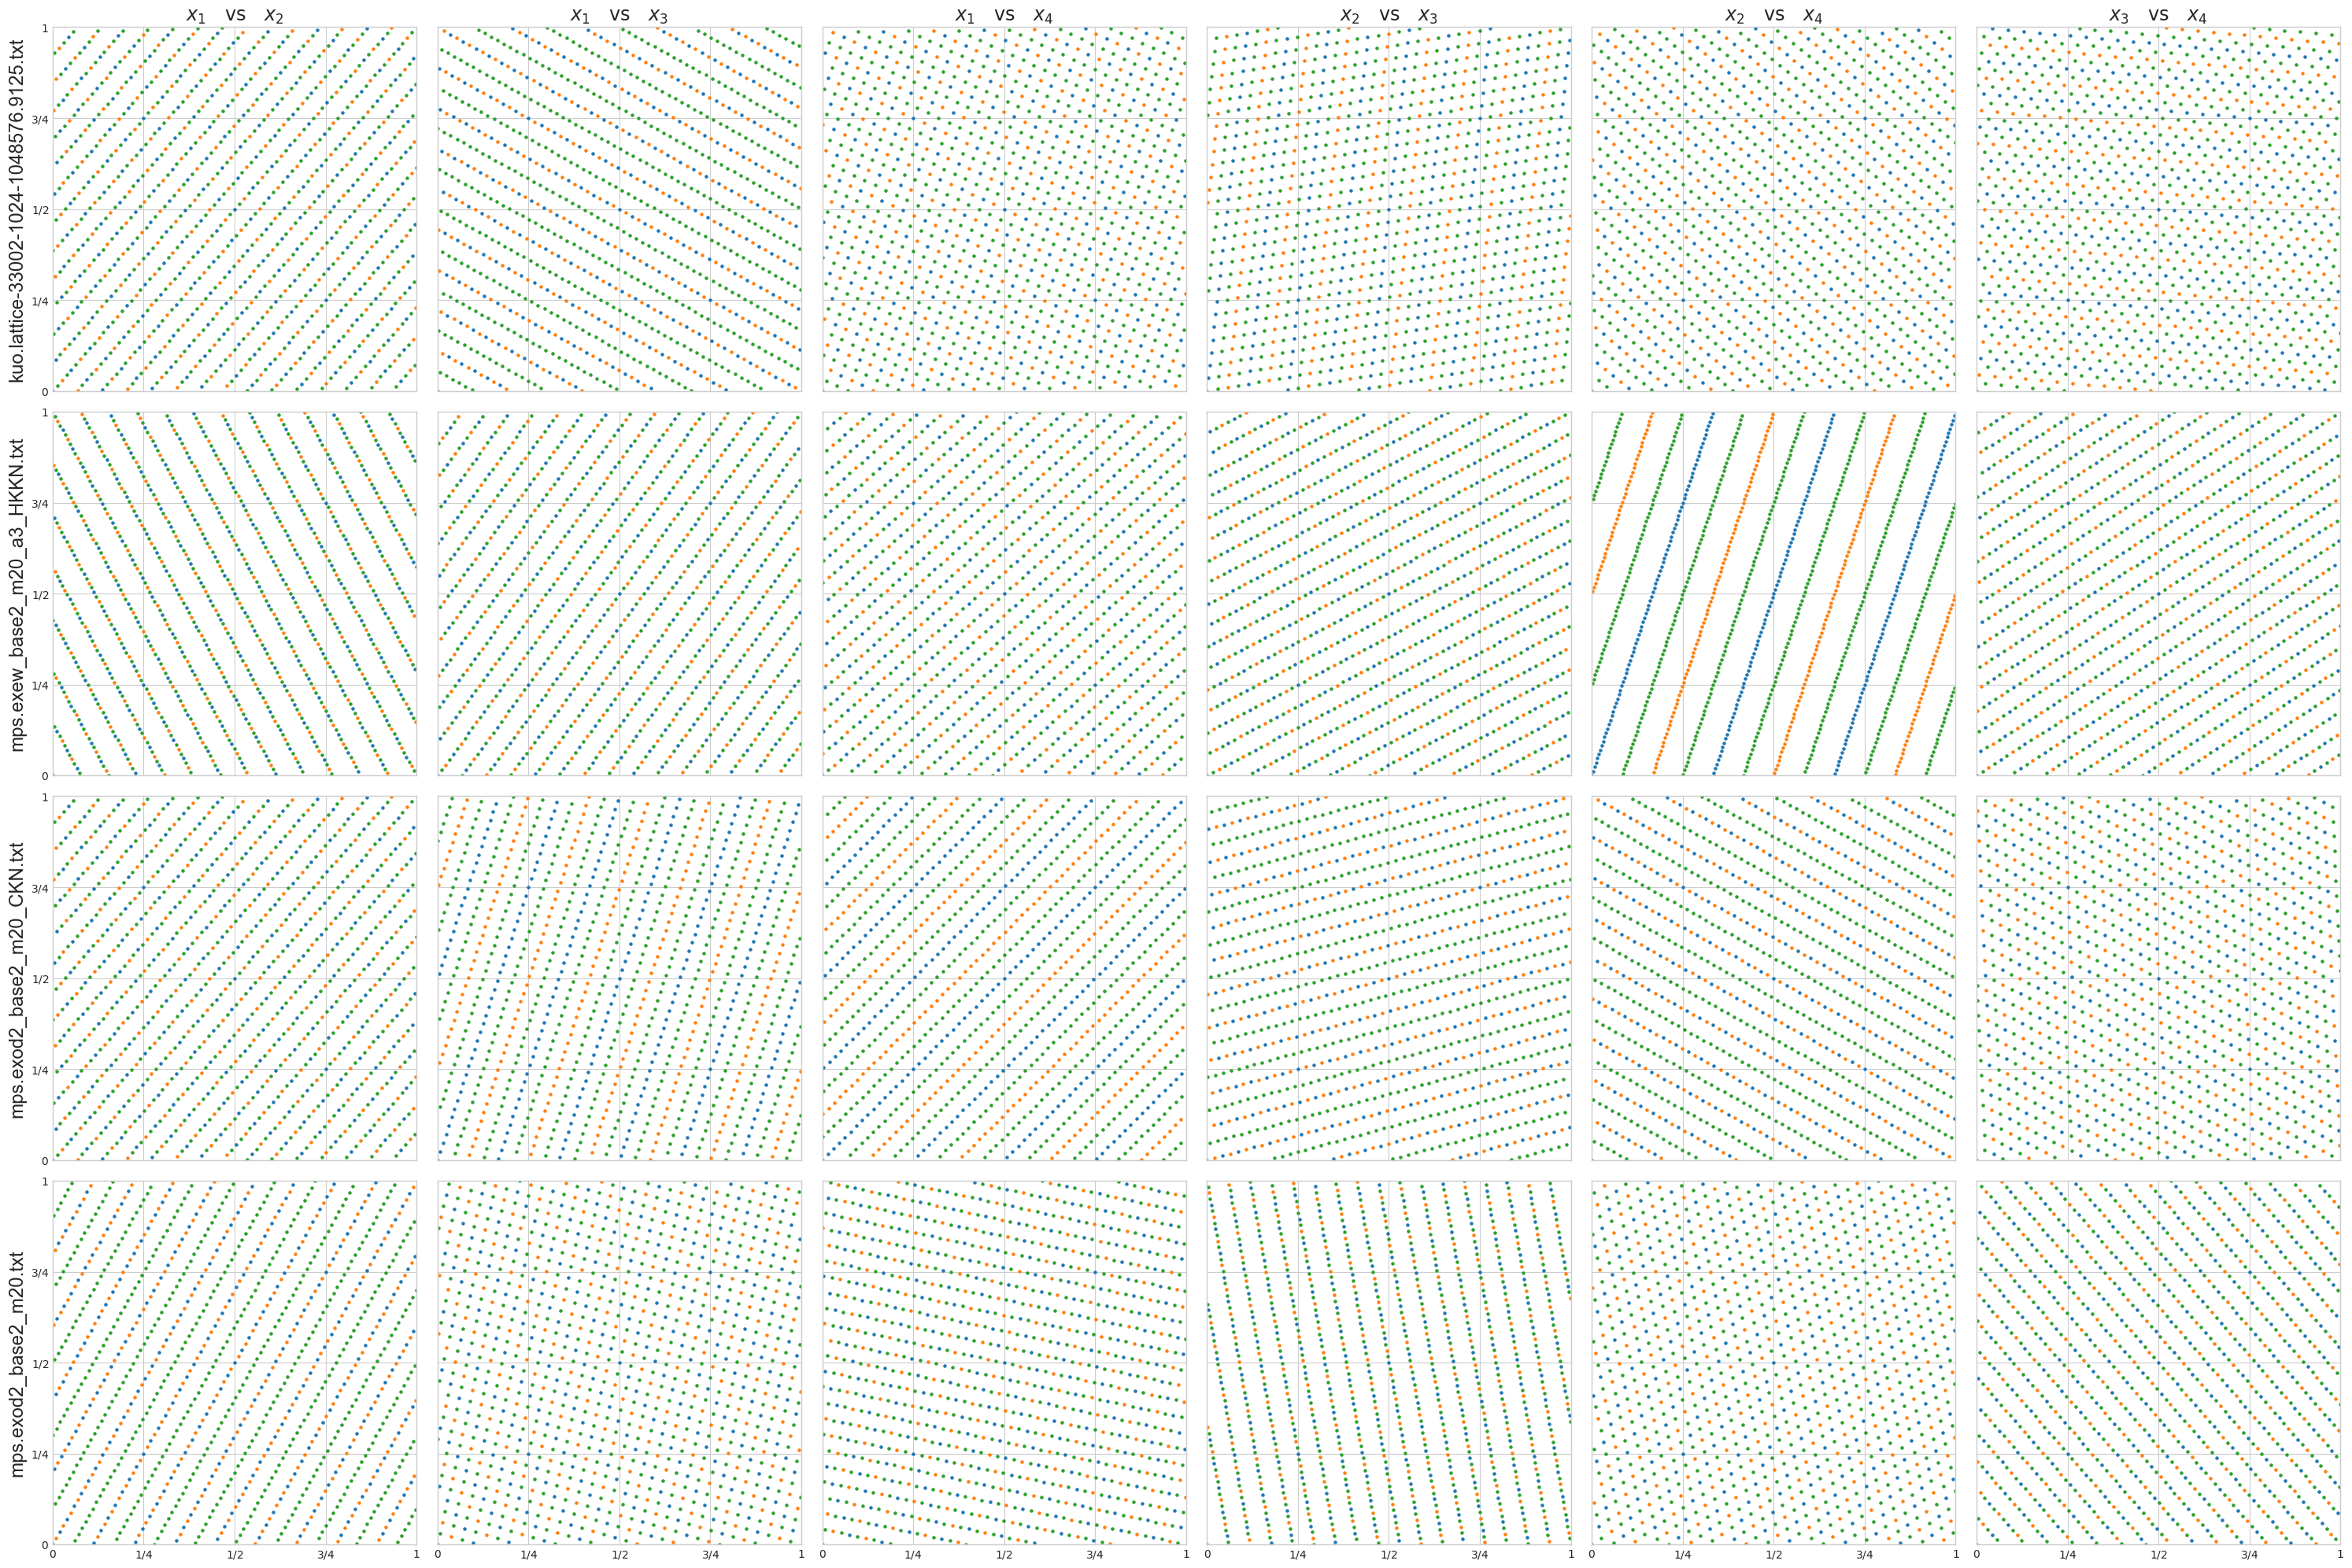

In [7]:
files = [
    "kuo.lattice-33002-1024-1048576.9125.txt",
    "mps.exew_base2_m20_a3_HKKN.txt",
    "mps.exod2_base2_m20_CKN.txt",
    "mps.exod2_base2_m20.txt",
]
generators = [qp.Lattice(d,randomize=False,generating_vector=file) for file in files]
plot_extensible_projections(generators,files,n=n)

### Digital Nets

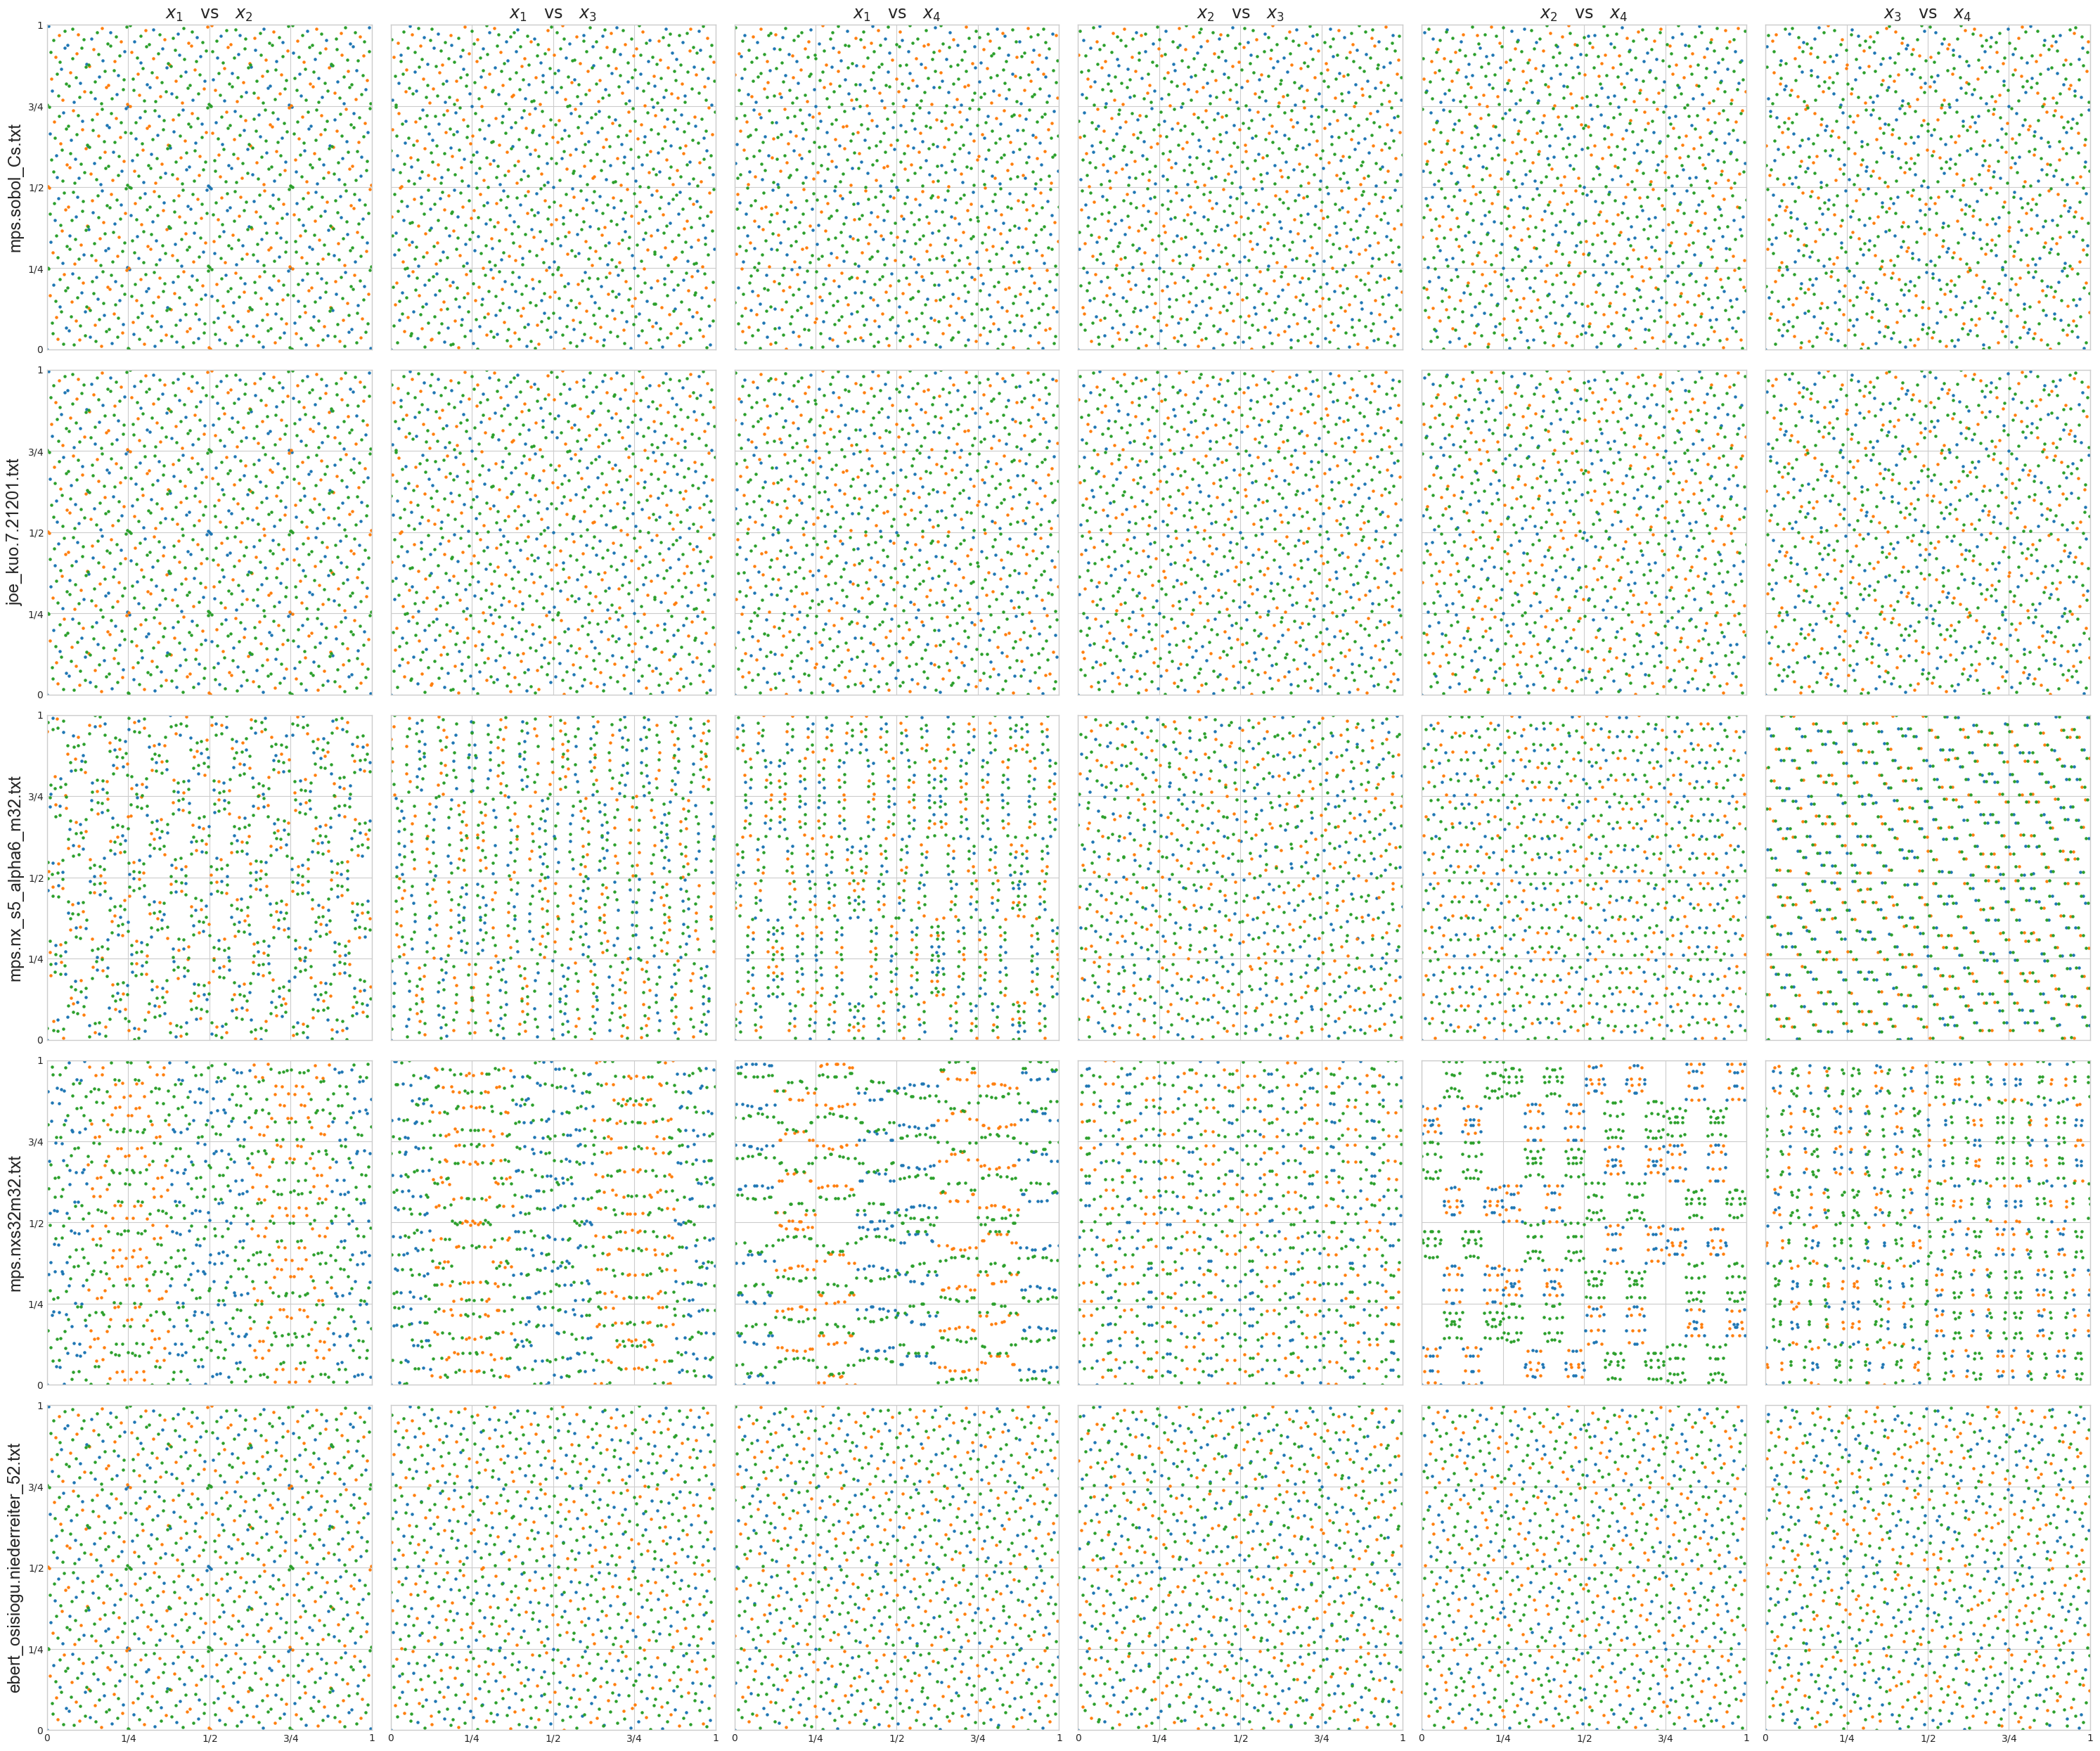

In [8]:
files = [
    "mps.sobol_Cs.txt",
    "joe_kuo.7.21201.txt",
    "mps.nx_s5_alpha6_m32.txt",
    "mps.nxs32m32.txt",
    "ebert_osisiogu.niederreiter_52.txt",
]
generators = [qp.DigitalNetB2(d,randomize=False,generating_matrices=file) for file in files]
plot_extensible_projections(generators,files,n=n)